# Linear regression with a single neuron — Solutions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1: Compute the gradients

**Step 1: Identify the individual derivatives.**

$$
\frac{\partial \mathcal{L}}{\partial \hat{y}} = \frac{\partial}{\partial \hat{y}} \left[ \frac{1}{2}(y - \hat{y})^2 \right] = -(y - \hat{y}) = (\hat{y} - y)
$$

$$
\frac{\partial \hat{y}}{\partial z} = \frac{\partial z}{\partial z} = 1
$$

$$
\frac{\partial z}{\partial w_0} = \frac{\partial}{\partial w_0}(w_1 x + w_0) = 1, \qquad
\frac{\partial z}{\partial w_1} = \frac{\partial}{\partial w_1}(w_1 x + w_0) = x
$$

**Step 2: Apply the chain rule.**

For $w_0$:

$$
\frac{\partial \mathcal{L}}{\partial w_0} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_0} = (\hat{y} - y) \cdot 1 \cdot 1 = (\hat{y} - y)
$$

For $w_1$:

$$
\frac{\partial \mathcal{L}}{\partial w_1} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_1} = (\hat{y} - y) \cdot 1 \cdot x = x(\hat{y} - y)
$$

## Generate training data

In [2]:
N = 200
rng = np.random.default_rng(42)
x_data = rng.uniform(0, 1, N)

true_slope = 3.0
true_intercept = 0.0
noise_std = 0.1

y_data = true_slope * x_data + true_intercept + rng.normal(0, noise_std, N)

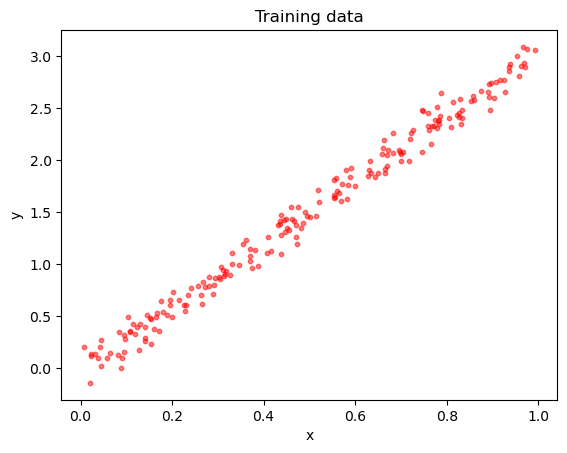

In [3]:
plt.scatter(x_data, y_data, c="red", alpha=0.5, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training data")
plt.show()

## Exercise 2: Stochastic gradient descent

### a) Gradient and loss functions

In [4]:
def dL_dw0(y, y_hat):
    return y_hat - y


def dL_dw1(y, y_hat, x):
    return x * (y_hat - y)


def loss_fn(y, y_hat):
    return 0.5 * (y - y_hat) ** 2

### b) Run SGD

In [5]:
w_0, w_1 = -5.0, 5.0
gamma = 0.1

losses = []
for x_i, y_i in zip(x_data, y_data):
    y_hat = w_0 + w_1 * x_i
    loss = loss_fn(y_i, y_hat)
    w_0 = w_0 - gamma * dL_dw0(y_i, y_hat)
    w_1 = w_1 - gamma * dL_dw1(y_i, y_hat, x_i)
    losses.append(loss)

### c) Plot results

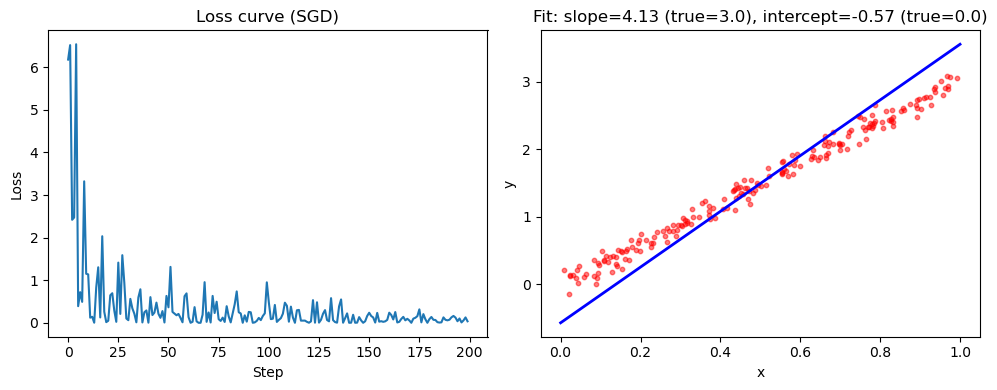

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(losses)
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Loss curve (SGD)")

ax2.scatter(x_data, y_data, c="red", alpha=0.5, s=10)
x_line = np.linspace(0, 1, 100)
ax2.plot(x_line, w_0 + w_1 * x_line, "b-", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title(
    f"Fit: slope={w_1:.2f} (true={true_slope}), intercept={w_0:.2f} (true={true_intercept})"
)

plt.tight_layout()
plt.show()

## Exercise 3: Batch gradient descent

### a) Batch gradient functions

In [7]:
def batch_dL_dw0(y, y_hat):
    return np.mean(y_hat - y)


def batch_dL_dw1(y, y_hat, x):
    return np.mean(x * (y_hat - y))


def batch_loss_fn(y, y_hat):
    return 0.5 * np.mean((y - y_hat) ** 2)

### b) Train with batch GD

In [8]:
w_0, w_1 = -5.0, 5.0
gamma = 0.1
n_epochs = 1000

losses = []
for epoch in range(n_epochs):
    y_hat = w_0 + w_1 * x_data
    loss = batch_loss_fn(y_data, y_hat)
    w_0 = w_0 - gamma * batch_dL_dw0(y_data, y_hat)
    w_1 = w_1 - gamma * batch_dL_dw1(y_data, y_hat, x_data)
    losses.append(loss)

### c) Plot results

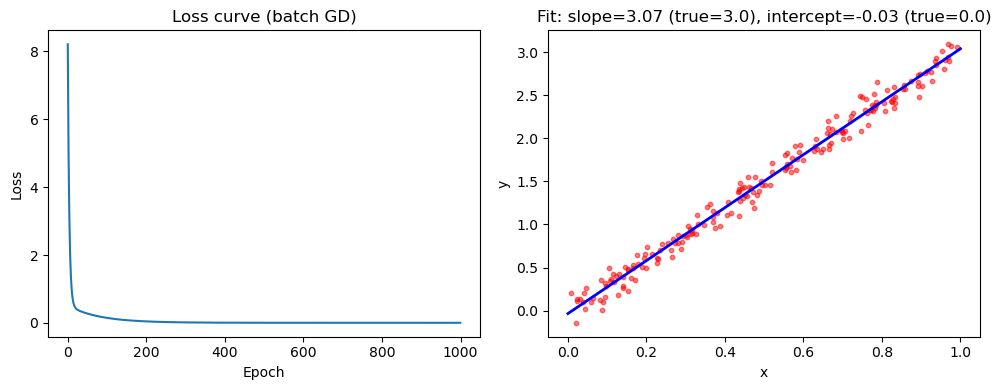

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss curve (batch GD)")

ax2.scatter(x_data, y_data, c="red", alpha=0.5, s=10)
x_line = np.linspace(0, 1, 100)
ax2.plot(x_line, w_0 + w_1 * x_line, "b-", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title(
    f"Fit: slope={w_1:.2f} (true={true_slope}), intercept={w_0:.2f} (true={true_intercept})"
)

plt.tight_layout()
plt.show()

## Visualizing the loss surface

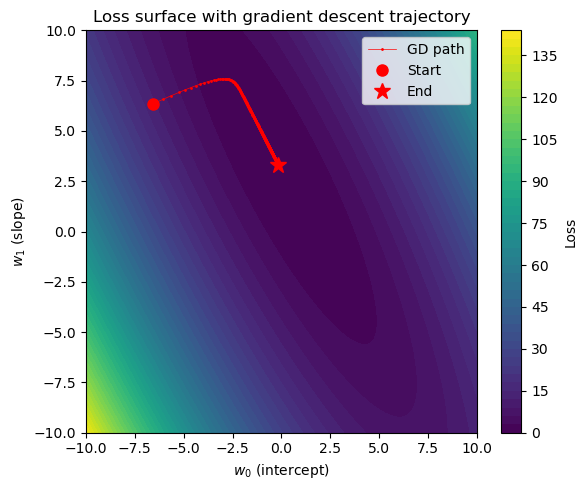

In [10]:
# --- Loss surface visualization (just run this cell) ---

# Re-run gradient descent and store the weight trajectory
w_0_init, w_1_init = rng.uniform(-8, 8), rng.uniform(-8, 8)
w_0, w_1 = w_0_init, w_1_init
gamma = 0.1
trajectory = [(w_0, w_1)]

for epoch in range(500):
    y_hat = w_0 + w_1 * x_data
    w_0 = w_0 - gamma * np.mean(y_hat - y_data)
    w_1 = w_1 - gamma * np.mean(x_data * (y_hat - y_data))
    trajectory.append((w_0, w_1))

trajectory = np.array(trajectory)

# Compute loss on a grid of (w0, w1) values
resolution = 100
w0_grid = np.linspace(-10, 10, resolution)
w1_grid = np.linspace(-10, 10, resolution)
W0, W1 = np.meshgrid(w0_grid, w1_grid)

loss_grid = np.zeros_like(W0)
for i in range(resolution):
    for j in range(resolution):
        y_hat = W0[i, j] + W1[i, j] * x_data
        loss_grid[i, j] = 0.5 * np.mean((y_data - y_hat) ** 2)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
contour = ax.contourf(W0, W1, loss_grid, levels=50, cmap="viridis")
fig.colorbar(contour, ax=ax, label="Loss")
ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    "r.-",
    markersize=2,
    linewidth=0.5,
    label="GD path",
)
ax.plot(trajectory[0, 0], trajectory[0, 1], "ro", markersize=8, label="Start")
ax.plot(trajectory[-1, 0], trajectory[-1, 1], "r*", markersize=12, label="End")
ax.set_xlabel("$w_0$ (intercept)")
ax.set_ylabel("$w_1$ (slope)")
ax.set_title("Loss surface with gradient descent trajectory")
ax.legend()
plt.tight_layout()
plt.show()

## Exercise 4: Verify MSE ↔ OLS equivalence

In [11]:
# OLS solution
x_mean = np.mean(x_data)
y_mean = np.mean(y_data)
w1_ols = np.sum((x_data - x_mean) * (y_data - y_mean)) / np.sum((x_data - x_mean) ** 2)
w0_ols = y_mean - w1_ols * x_mean

print(f"Gradient descent: w_0 = {w_0:.4f}, w_1 = {w_1:.4f}")
print(f"OLS solution:     w_0 = {w0_ols:.4f}, w_1 = {w1_ols:.4f}")
print(
    f"Difference:       |Δw_0| = {abs(w_0 - w0_ols):.6f}, |Δw_1| = {abs(w_1 - w1_ols):.6f}"
)

Gradient descent: w_0 = -0.1490, w_1 = 3.2900
OLS solution:     w_0 = -0.0309, w_1 = 3.0659
Difference:       |Δw_0| = 0.118122, |Δw_1| = 0.224127
